<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/Exp_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving t1.mp4 to t1 (2).mp4
Processing motion detection...
Done! Output saved as output_motion.avi
Final Output Frame:


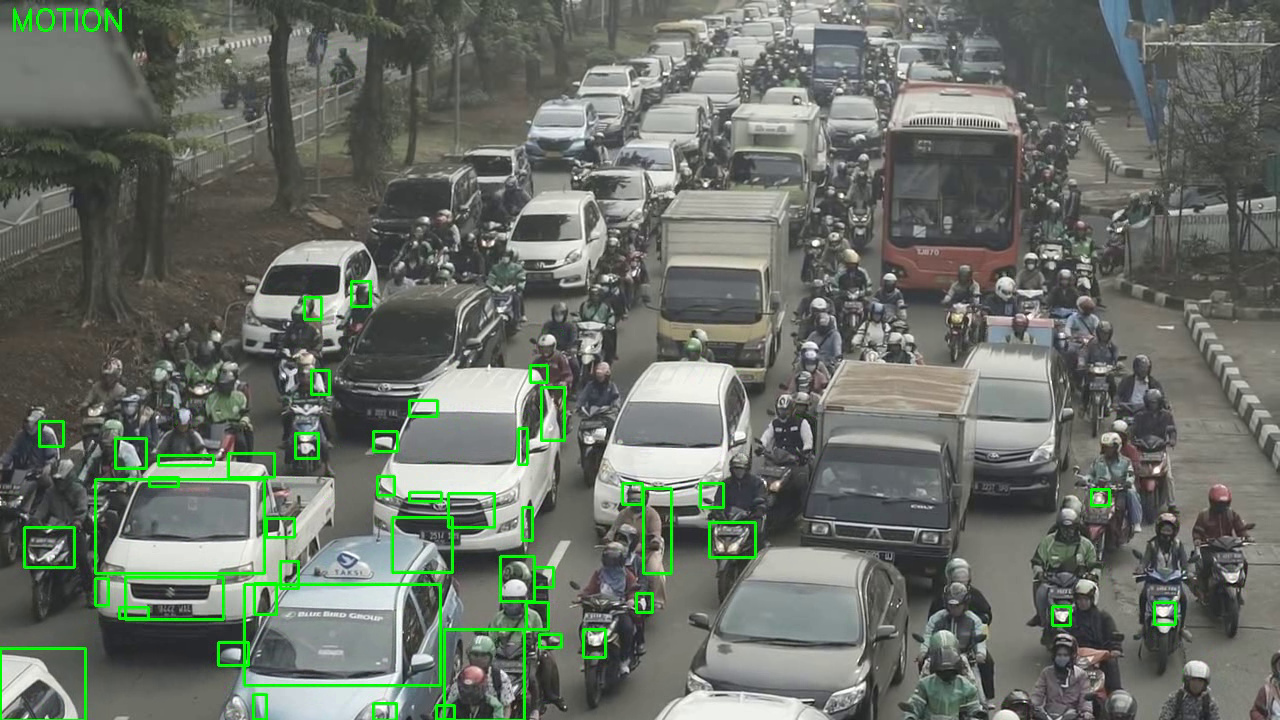

In [3]:
from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np

video_path = list(uploaded.keys())[0]

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error opening video")
    exit()

# Get video properties
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

# Save output video (IMPORTANT for GitHub)
out = cv2.VideoWriter(
    "output_motion.avi",
    cv2.VideoWriter_fourcc(*"XVID"),
    fps,
    (width, height)
)

ret, first_frame = cap.read()
if not ret:
    print("Error reading video")
    exit()

prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
prev_gray = cv2.GaussianBlur(prev_gray, (15,15), 0)

print("Processing motion detection...")

while True:

    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (15,15), 0)

    diff = cv2.absdiff(prev_gray, gray)

    thresh = cv2.threshold(diff, 15, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.dilate(thresh, None, iterations=3)

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    motion = False

    for c in contours:
        if cv2.contourArea(c) > 200:
            motion = True
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(frame, (x,y), (x+w,y+h), (0,255,0), 2)

    text = "MOTION" if motion else "NO MOTION"
    color = (0,255,0) if motion else (0,0,255)

    cv2.putText(frame, text, (10,30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

    out.write(frame)

    prev_gray = gray

cap.release()
out.release()

print("Done! Output saved as output_motion.avi")

import cv2
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture("output_motion.avi")

last_frame = None

while True:
    ret, frame = cap.read()
    if not ret:
        break
    last_frame = frame

cap.release()

print("Final Output Frame:")
cv2_imshow(last_frame)